# Dataset Explorer: GoEmotions + Financial PhraseBank

**Project:** Domain-Adaptive Sentiment Analysis using Transformers and LLMs
**Datasets:**
- **General-Domain:** GoEmotions (58k Reddit comments, 27 emotion labels).
- **Domain-Specific:** Financial PhraseBank (4,845 financial news sentences).

Load both datasets, explore their structure, maps GoEmotions to a 3-class financial sentiment scheme, and performs cross-domain EDA.

## 1. Setup & Installation.

Run the cell below once to install the required libraries.

In [11]:
pip install datasets pandas matplotlib seaborn wordcloud -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [12]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'datasets==2.21.0', 'pandas', 'matplotlib', 'seaborn', 'wordcloud', '-q'])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print('All imports loaded successfully.')

All imports loaded successfully.


# Part A: Financial PhraseBank (Domain-Specific Dataset).

The Financial PhraseBank dataset contains 4,845 sentences from English financial news, annotated by 16 finance professionals as **Positive**, **Negative**, or **Neutral** from an investor's viewpoint.

The `takala` version on HuggingFace provides 4 subsets based on annotator agreement:
- `sentences_50agree` - 4,846 samples (lowest threshold, largest set).
- `sentences_66agree` - 4,217 samples.
- `sentences_75agree` - 3,453 samples.
- `sentences_allagree` - 2,264 samples (100% consensus, smallest but cleanest).

### A1. Load the dataset.

In [13]:
# Load with 50% agreement (largest subset).
# will Change to 'sentences_66agree', 'sentences_75agree', or 'sentences_allagree' as needed.
fpb = load_dataset('takala/financial_phrasebank', 'sentences_50agree', trust_remote_code=True)

# Convert to pandas.
fpb_df = pd.DataFrame(fpb['train'])
fpb_df.columns = ['sentence', 'label']

# Map numeric labels to readable text.
fpb_label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
fpb_df['sentiment'] = fpb_df['label'].map(fpb_label_map)

print(f'Total samples: {len(fpb_df)}')
print(f'Columns: {list(fpb_df.columns)}')
fpb_df.head()

Total samples: 4846
Columns: ['sentence', 'label', 'sentiment']


,sentence,label,sentiment
0,"According to Gran , the company has no plans t...",1,Neutral
1,Technopolis plans to develop in stages an area...,1,Neutral
2,The international electronic industry company ...,0,Negative
3,With the new production plant the company woul...,2,Positive
4,According to the company 's updated strategy f...,2,Positive


### A2. Class distribution.

In [14]:
print('class distribution:')
print(fpb_df['sentiment'].value_counts())
print(f'\nPercentages:')
print((fpb_df['sentiment'].value_counts(normalize=True) * 100).round(1))


class distribution:
sentiment
Neutral     2879
Positive    1363
Negative     604
Name: count, dtype: int64

Percentages:
sentiment
Neutral     59.4
Positive    28.1
Negative    12.5
Name: proportion, dtype: float64


### A3. Text length analysis.
(text length is important for tokenisation and padding strategies)

In [15]:
fpb_df['word_count'] = fpb_df['sentence'].apply(lambda x: len(x.split()))
fpb_df['char_count'] = fpb_df['sentence'].apply(len)

print('Text Length Statistics:')
fpb_df[['word_count', 'char_count']].describe().round(1)

Text Length Statistics:


,word_count,char_count
count,4846.0,4846.0
mean,23.1,128.1
std,10.0,56.5
min,2.0,9.0
25%,16.0,84.0
50%,21.0,119.0
75%,29.0,163.0
max,81.0,315.0


### A4. Visualise Financial PhraseBank.

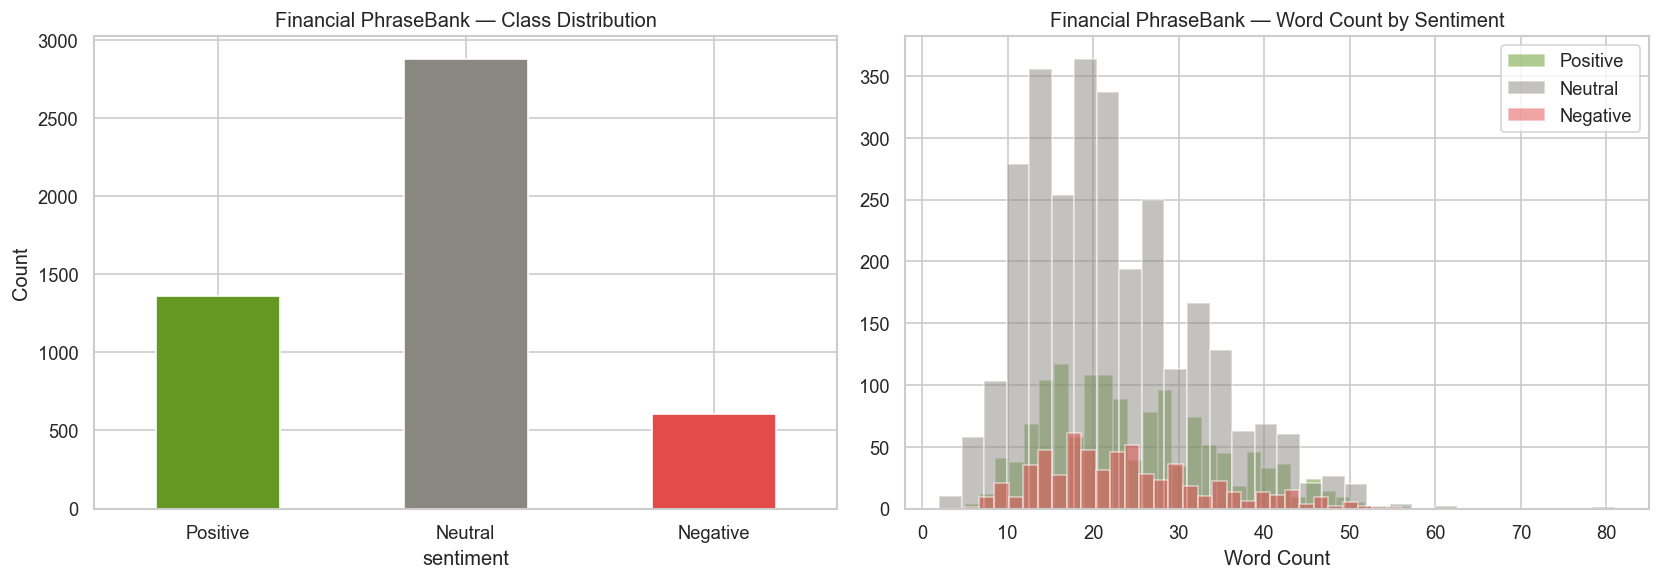

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
colors = {'Negative': '#E24B4A', 'Neutral': '#888780', 'Positive': '#639922'}
order = ['Positive', 'Neutral', 'Negative']
fpb_df['sentiment'].value_counts().reindex(order).plot(
    kind='bar', ax=axes[0], color=[colors[s] for s in order])
axes[0].set_title('Financial PhraseBank — Class Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Text length by sentiment.
for sentiment in order:
    subset = fpb_df[fpb_df['sentiment'] == sentiment]
    axes[1].hist(subset['word_count'], bins=30, alpha=0.5, label=sentiment, color=colors[sentiment])
axes[1].set_title('Financial PhraseBank — Word Count by Sentiment')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### A5. Compare agreement levels.
how does the class distribution shift when we require higher annotator consensus?.

In [17]:
agreement_data = []
for config in ['sentences_50agree', 'sentences_66agree', 'sentences_75agree', 'sentences_allagree']:
    ds = load_dataset('takala/financial_phrasebank', config, trust_remote_code=True)
    df_temp = pd.DataFrame(ds['train'])
    df_temp.columns = ['sentence', 'label']
    df_temp['sentiment'] = df_temp['label'].map(fpb_label_map)
    counts = df_temp['sentiment'].value_counts()
    agreement_data.append({
        'Agreement': config.replace('sentences_', '').replace('agree', '% agree'),
        'Total': len(df_temp),
        'Positive': counts.get('Positive', 0),
        'Neutral': counts.get('Neutral', 0),
        'Negative': counts.get('Negative', 0)
    })

agreement_df = pd.DataFrame(agreement_data)
print('Agreement Level Comparison:')
agreement_df

Agreement Level Comparison:


,Agreement,Total,Positive,Neutral,Negative
0,50% agree,4846,1363,2879,604
1,66% agree,4217,1168,2535,514
2,75% agree,3453,887,2146,420
3,all% agree,2264,570,1391,303



# Part B: GoEmotions (General-Domain Dataset).

GoEmotions (Demszky et al., ACL 2020) is a dataset of 58k Reddit comments labelled for **27 emotion categories + Neutral**. It is multi-label, a single comment can be tagged with multiple emotions.

This will serve as our **general-domain** dataset. We'll later map the 28 labels down to 6 classes to align with the financial sentiment task.

### B1. Load the dataset.

In [18]:
goemotions = load_dataset('google-research-datasets/go_emotions', 'simplified')

ge_train = pd.DataFrame(goemotions['train'])
ge_val = pd.DataFrame(goemotions['validation'])
ge_test = pd.DataFrame(goemotions['test'])

print(f'Train:      {len(ge_train)} samples')
print(f'Validation: {len(ge_val)} samples')
print(f'Test:       {len(ge_test)} samples')
print(f'Total:      {len(ge_train) + len(ge_val) + len(ge_test)} samples')
print(f'\nColumns: {list(ge_train.columns)}')
ge_train.head()

Train:      43410 samples
Validation: 5426 samples
Test:       5427 samples
Total:      54263 samples

Columns: ['text', 'labels', 'id']


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


### B2. Explore the emotion labels.
Each sample has a list of label IDs. Let's see what they are and how often each appears.

In [19]:
emotion_labels = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse',
    'sadness', 'surprise', 'neutral'
]

print('All Labels:')
for i, label in enumerate(emotion_labels):
    print(f'  {i:2d}: {label}')

All Labels:
   0: admiration
   1: amusement
   2: anger
   3: annoyance
   4: approval
   5: caring
   6: confusion
   7: curiosity
   8: desire
   9: disappointment
  10: disapproval
  11: disgust
  12: embarrassment
  13: excitement
  14: fear
  15: gratitude
  16: grief
  17: joy
  18: love
  19: nervousness
  20: optimism
  21: pride
  22: realization
  23: relief
  24: remorse
  25: sadness
  26: surprise
  27: neutral


In [24]:
# Count label frequencies across all training samples.
all_labels = []
for label_list in ge_train['labels']:
    all_labels.extend(label_list)

label_counts = Counter(all_labels)
label_freq = pd.DataFrame([
    {'emotion': emotion_labels[k], 'count': v}
    for k, v in label_counts.items()
]).sort_values('count', ascending=False).reset_index(drop=True)

print('Label Frequencies (all 28):')
label_freq

Label Frequencies (all 28):


,emotion,count
0,neutral,14219
1,admiration,4130
2,approval,2939
3,gratitude,2662
4,annoyance,2470
5,amusement,2328
6,curiosity,2191
7,love,2086
8,disapproval,2022
9,optimism,1581


### B3. Visualise GoEmotions label distribution

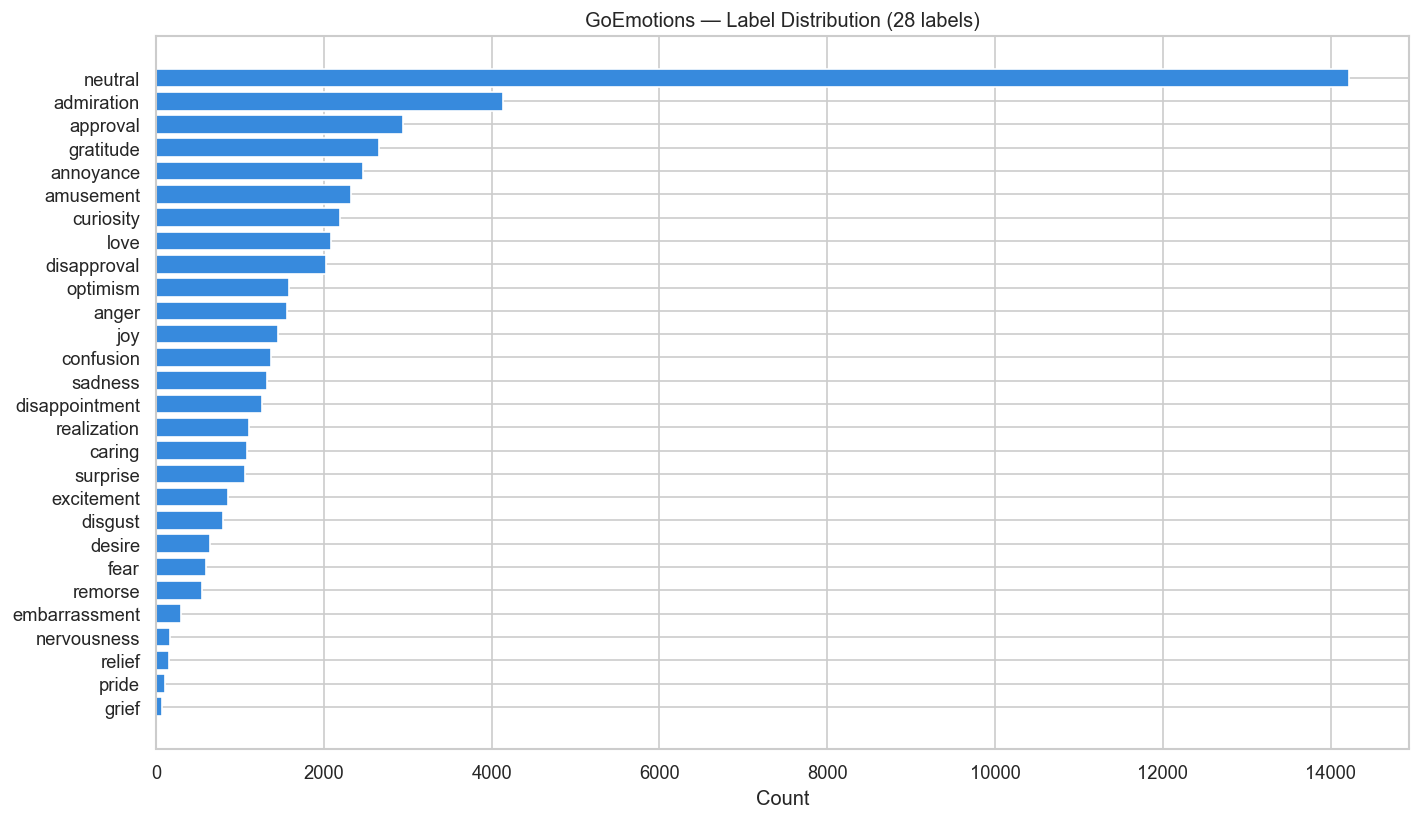

In [26]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(label_freq['emotion'], label_freq['count'], color='#378ADD')
ax.set_xlabel('Count')
ax.set_title('GoEmotions — Label Distribution (28 labels)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### B4. Text length analysis.

In [27]:
ge_train['word_count'] = ge_train['text'].apply(lambda x: len(x.split()))
ge_train['char_count'] = ge_train['text'].apply(len)

print('GoEmotions Text Length Statistics:')
ge_train[['word_count', 'char_count']].describe().round(1)

GoEmotions Text Length Statistics:


,word_count,char_count
count,43410.0,43410.0
mean,12.8,68.4
std,6.7,36.7
min,1.0,2.0
25%,7.0,38.0
50%,12.0,65.0
75%,18.0,96.0
max,33.0,703.0
